# 1. Library

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter


# Data preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

# Train / validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_predict
)



# Imbalanced data
from imblearn.over_sampling import (
    SMOTE,
    SMOTENC
)


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score
)

# 2. EDA

In [2]:
df = pd.read_csv(r'C:\Users\User\Downloads\archive (1)\bs140513_032310.csv')

In [3]:
cat_cols_raw = [
    "customer",
    "age",
    "gender",
    "zipcodeOri",
    "merchant",
    "zipMerchant",
    "category"
]

for col in cat_cols_raw:
    df[col] = df[col].astype(str).str.strip("'")

In [4]:
df.head(5)

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0


In [5]:
df.nunique()

step             180
customer        4112
age                8
gender             4
zipcodeOri         1
merchant          50
zipMerchant        1
category          15
amount         23767
fraud              2
dtype: int64

In [6]:
df.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [7]:
df.describe()

,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
fraud_count = df["fraud"].value_counts()

print(fraud_count)

print("\nFraud percentage:")
print(df["fraud"].value_counts(normalize=True) * 100)

fraud
0    587443
1      7200
Name: count, dtype: int64

Fraud percentage:
fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64


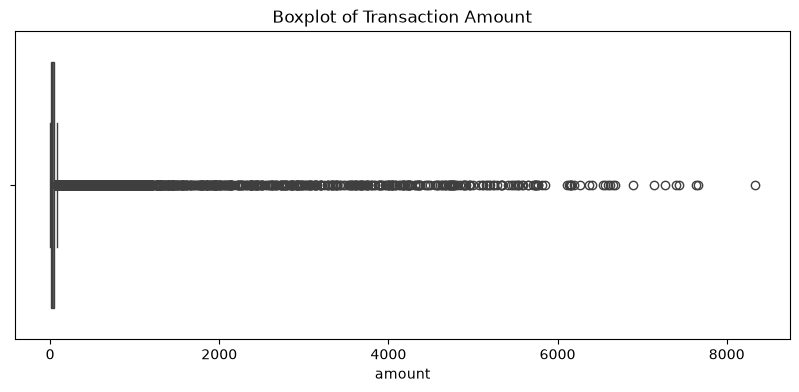

In [10]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="amount"
)

plt.title("Boxplot of Transaction Amount")

plt.show()

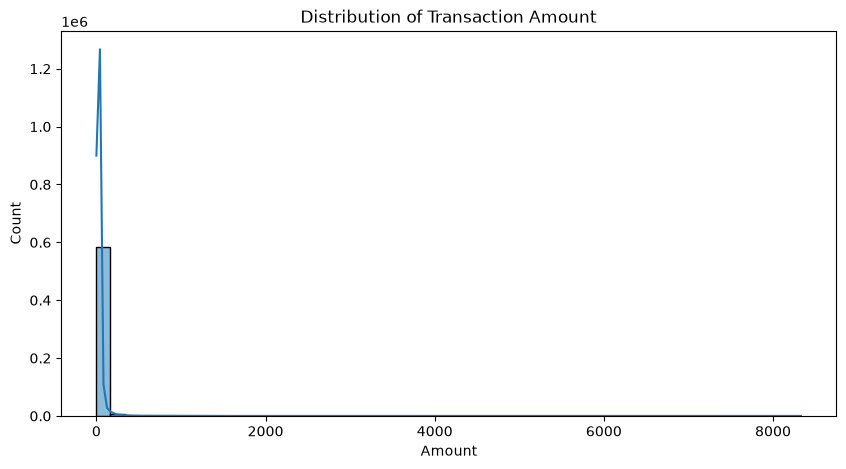

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")

plt.show()

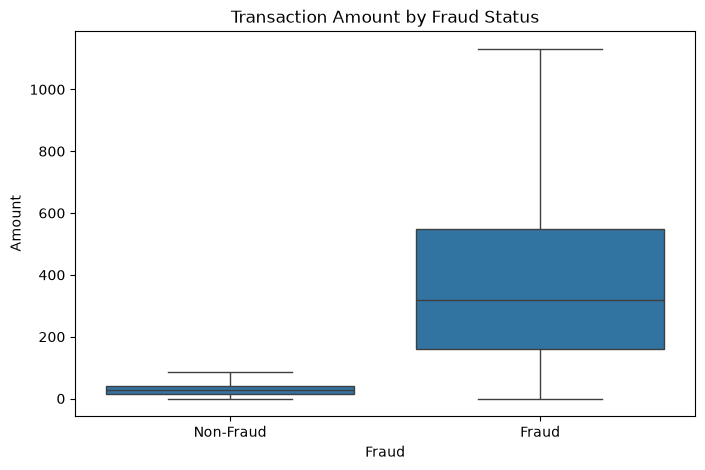

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraud",
    y="amount",
    showfliers=False
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Amount")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])

plt.show()

In [13]:
category_analysis = (
    df.groupby("category")
      .agg(
          total_transactions=("fraud", "count"),
          fraud_transactions=("fraud", "sum"),
          fraud_rate=("fraud", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
)

display(category_analysis)

,total_transactions,fraud_transactions,fraud_rate
category,,,
es_leisure,499,474,0.949900
es_travel,728,578,0.793956
es_sportsandtoys,4002,1982,0.495252
es_hotelservices,1744,548,0.314220
es_otherservices,912,228,0.250000
es_home,1986,302,0.152064
es_health,16133,1696,0.105126
es_tech,2370,158,0.066667
es_wellnessandbeauty,15086,718,0.047594


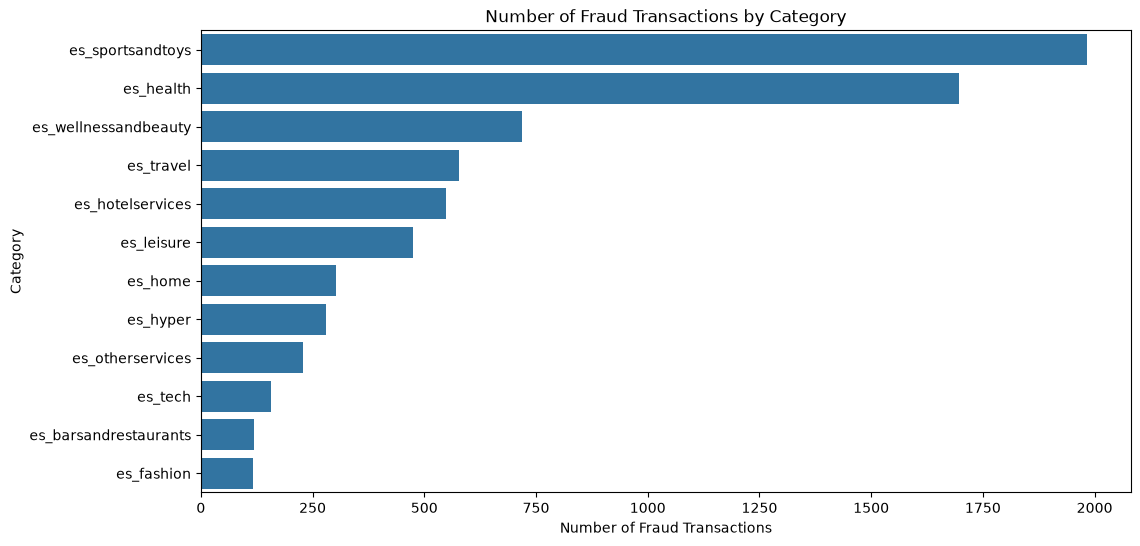

In [14]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df[df["fraud"] == 1],
    y="category",
    order=df[df["fraud"] == 1]["category"].value_counts().index
)

plt.title("Number of Fraud Transactions by Category")
plt.xlabel("Number of Fraud Transactions")
plt.ylabel("Category")

plt.show()

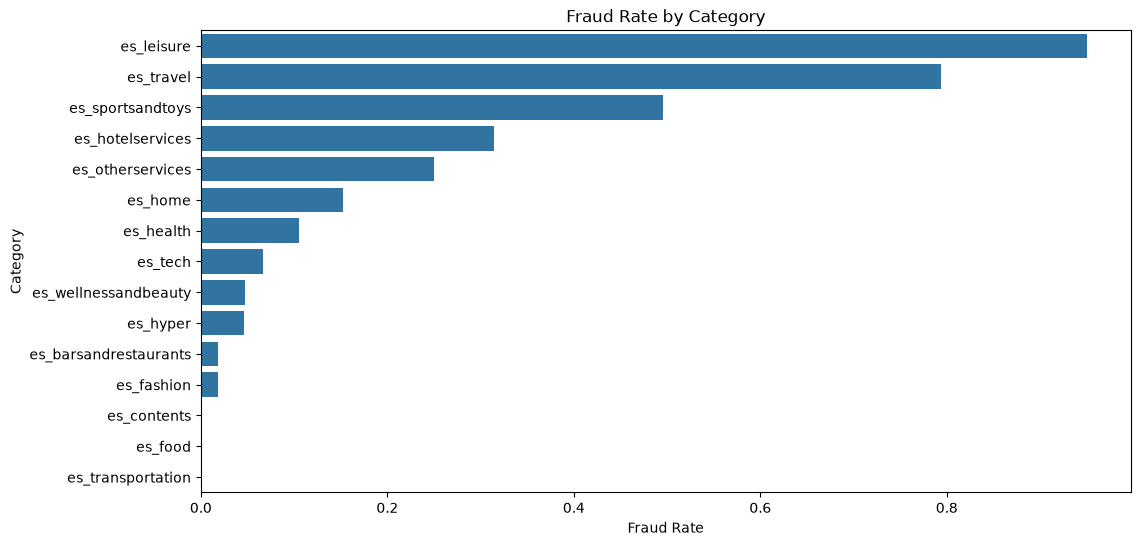

In [15]:
fraud_rate_category = (
    df.groupby("category")["fraud"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=fraud_rate_category.values,
    y=fraud_rate_category.index
)

plt.title("Fraud Rate by Category")
plt.xlabel("Fraud Rate")
plt.ylabel("Category")

plt.show()

In [16]:
gender_analysis = (
    df.groupby("gender")
      .agg(
          transactions=("fraud", "count"),
          fraud=("fraud", "sum"),
          fraud_rate=("fraud", "mean")
      )
)

display(gender_analysis)

,transactions,fraud,fraud_rate
gender,,,
E,1178,7,0.005942
F,324565,4758,0.014660
M,268385,2435,0.009073
U,515,0,0.000000


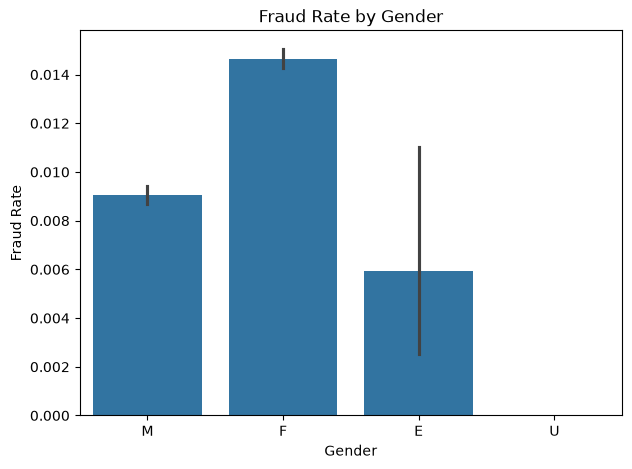

In [17]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="gender",
    y="fraud"
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")

plt.show()

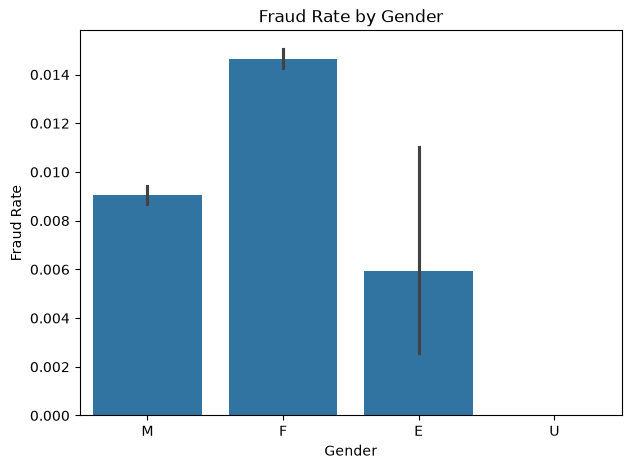

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="gender",
    y="fraud"
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")

plt.show()

In [19]:
age_analysis = (
    df.groupby("age")
      .agg(
          transactions=("fraud", "count"),
          fraud=("fraud", "sum"),
          fraud_rate=("fraud", "mean")
      )
      .sort_index()
)

display(age_analysis)

,transactions,fraud,fraud_rate
age,,,
0,2452,48,0.019576
1,58131,689,0.011853
2,187310,2344,0.012514
3,147131,1755,0.011928
4,109025,1410,0.012933
5,62642,686,0.010951
6,26774,261,0.009748
U,1178,7,0.005942


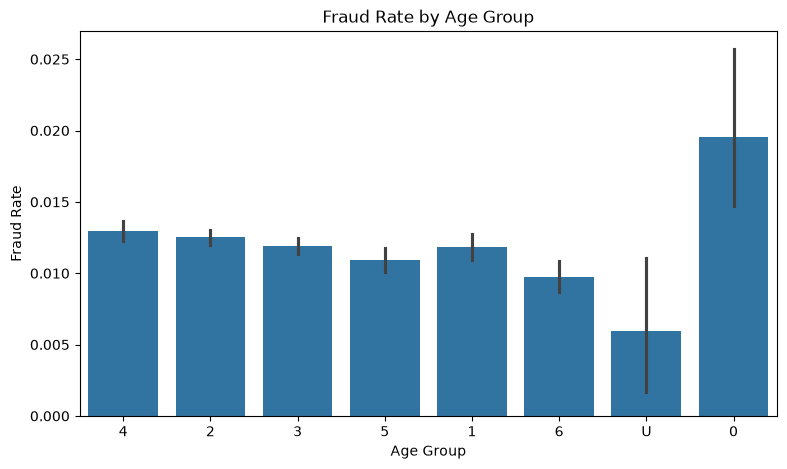

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="age",
    y="fraud"
)

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")

plt.show()

In [21]:
merchant_analysis = (
    df.groupby("merchant")
      .agg(
          total=("fraud", "count"),
          fraud=("fraud", "sum"),
          fraud_rate=("fraud", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
)

display(merchant_analysis.head(15))

,total,fraud,fraud_rate
merchant,,,
M1294758098,191,184,0.963351
M3697346,308,290,0.941558
M1873032707,250,216,0.864000
M732195782,608,518,0.851974
M980657600,1769,1472,0.832109
M1353266412,78,64,0.820513
M857378720,122,92,0.754098
M2080407379,48,36,0.750000
M2011752106,244,166,0.680328


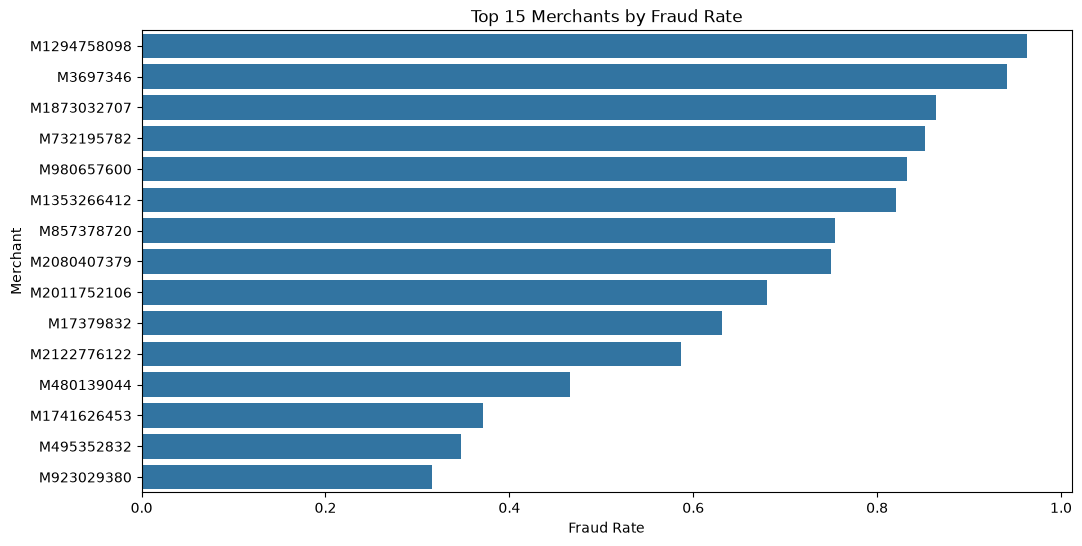

In [22]:
top_merchants = merchant_analysis.head(15).reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_merchants,
    x="fraud_rate",
    y="merchant"
)

plt.title("Top 15 Merchants by Fraud Rate")
plt.xlabel("Fraud Rate")
plt.ylabel("Merchant")

plt.show()

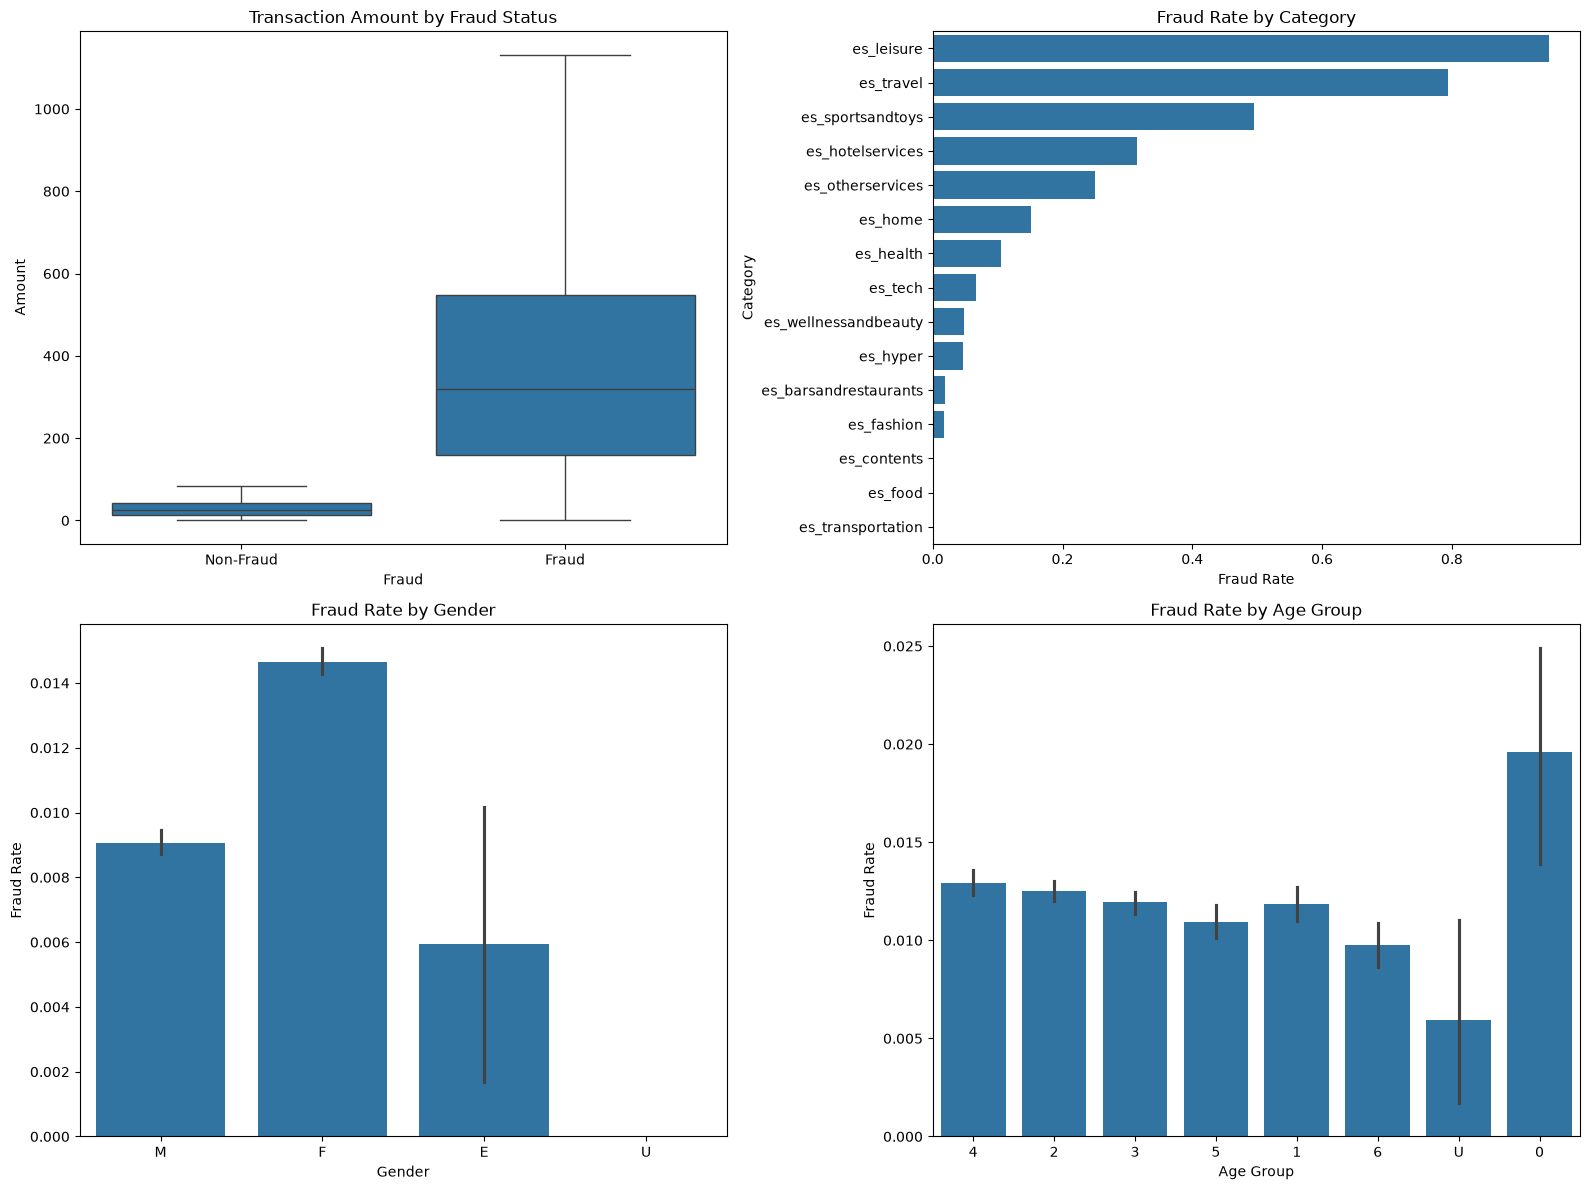

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =====================================
# 1. Amount by Fraud Status
# =====================================
sns.boxplot(
    data=df,
    x="fraud",
    y="amount",
    showfliers=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Transaction Amount by Fraud Status")
axes[0, 0].set_xlabel("Fraud")
axes[0, 0].set_ylabel("Amount")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Non-Fraud", "Fraud"])


# =====================================
# 2. Fraud Rate by Category
# =====================================
fraud_rate_category = (
    df.groupby("category")["fraud"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=fraud_rate_category.values,
    y=fraud_rate_category.index,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Fraud Rate by Category")
axes[0, 1].set_xlabel("Fraud Rate")
axes[0, 1].set_ylabel("Category")


# =====================================
# 3. Fraud Rate by Gender
# =====================================
sns.barplot(
    data=df,
    x="gender",
    y="fraud",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Fraud Rate by Gender")
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Fraud Rate")


# =====================================
# 4. Fraud Rate by Age Group
# =====================================
sns.barplot(
    data=df,
    x="age",
    y="fraud",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Fraud Rate by Age Group")
axes[1, 1].set_xlabel("Age Group")
axes[1, 1].set_ylabel("Fraud Rate")


plt.tight_layout()
plt.show()

# 3. Data preprocessing

In [24]:
df = df.drop(
    columns=[
        "customer",      
        "zipcodeOri",    
        "zipMerchant",   
        "merchant"    
    ]
)

In [25]:
X = df.drop(columns="fraud")
y = df["fraud"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [27]:
step_imputer = SimpleImputer(strategy="median")
step_scaler = StandardScaler()

X_train[["step"]] = step_imputer.fit_transform(
    X_train[["step"]]
)

X_test[["step"]] = step_imputer.transform(
    X_test[["step"]]
)

X_train[["step"]] = step_scaler.fit_transform(
    X_train[["step"]]
)

X_test[["step"]] = step_scaler.transform(
    X_test[["step"]]
)

In [28]:
amount_imputer = SimpleImputer(strategy="median")
amount_scaler = StandardScaler()

# Missing values
X_train[["amount"]] = amount_imputer.fit_transform(
    X_train[["amount"]]
)

X_test[["amount"]] = amount_imputer.transform(
    X_test[["amount"]]
)

# Log transformation
X_train["amount"] = np.log1p(X_train["amount"])
X_test["amount"] = np.log1p(X_test["amount"])

# Standardization
X_train[["amount"]] = amount_scaler.fit_transform(
    X_train[["amount"]]
)

X_test[["amount"]] = amount_scaler.transform(
    X_test[["amount"]]
)

In [29]:
categorical_cols = ["age", "gender", "category"]

In [30]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

In [31]:
dummy_columns = encoder.get_feature_names_out(
    categorical_cols
)

In [32]:
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=dummy_columns,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=dummy_columns,
    index=X_test.index
)

In [33]:
X_train_final = pd.concat(
    [
        X_train[["step", "amount"]],
        X_train_cat
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test[["step", "amount"]],
        X_test_cat
    ],
    axis=1
)

In [34]:
print(X_train_final.shape)
print(X_test_final.shape)

X_train_final.head()

(475714, 26)
(118929, 26)


,step,amount,age_1,age_2,age_3,age_4,age_5,age_6,age_U,gender_F,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty
296209,0.038934,-0.188473,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
329958,0.234754,0.162661,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
394447,0.587229,-0.015644,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
588673,1.625072,-1.116450,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
139286,-0.900999,-0.219819,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [35]:
print("Before SMOTE:")
print(Counter(y_train))

smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

Before SMOTE:
Counter({0: 469954, 1: 5760})

After SMOTE:
Counter({0: 469954, 1: 46995})


# 4.Model

## 4.1 Random forest

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_rf = rf_model.predict(X_test_final)

# Probability of fraud
y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]

print("Random Forest")
print("=============")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))


Random Forest
Confusion Matrix:
[[116589    900]
 [   353   1087]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    117489
           1       0.55      0.75      0.63      1440

    accuracy                           0.99    118929
   macro avg       0.77      0.87      0.81    118929
weighted avg       0.99      0.99      0.99    118929

ROC-AUC: 0.9790156093809255
PR-AUC: 0.7522365511918425


## 4.2 Logistic regression

In [37]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_log = log_model.predict(X_test_final)

# Probability of fraud
y_prob_log = log_model.predict_proba(X_test_final)[:, 1]

print("Logistic Regression")
print("===================")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("PR-AUC:", average_precision_score(y_test, y_prob_log))

Logistic Regression
Confusion Matrix:
[[115927   1562]
 [   247   1193]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    117489
           1       0.43      0.83      0.57      1440

    accuracy                           0.98    118929
   macro avg       0.72      0.91      0.78    118929
weighted avg       0.99      0.98      0.99    118929

ROC-AUC: 0.9908829762786303
PR-AUC: 0.7307730688502871


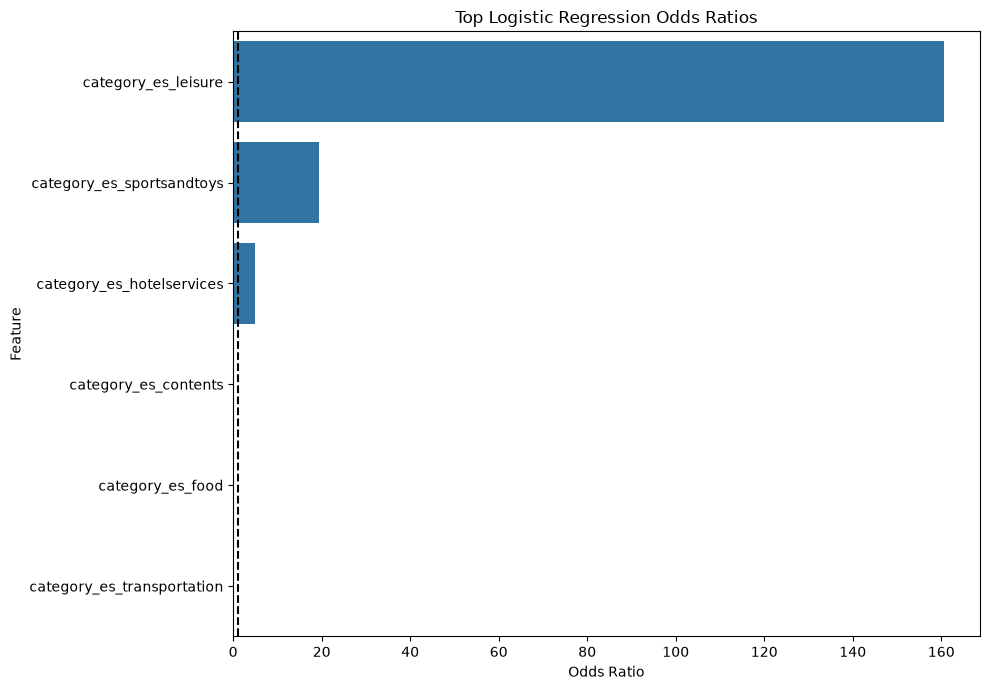

In [38]:
# Create Odds Ratio dataframe
or_df = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Coefficient": log_model.coef_[0]
})

or_df["Odds_Ratio"] = np.exp(or_df["Coefficient"])
or_df["Importance"] = or_df["Coefficient"].abs()

# Top 15 strongest effects
top_or = (
    or_df
    .sort_values("Importance", ascending=False)
    .head(6)
    .sort_values("Odds_Ratio", ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_or,
    x="Odds_Ratio",
    y="Feature",
    order=top_or["Feature"]
)

plt.axvline(
    1,
    color="black",
    linestyle="--"
)

plt.title("Top Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 5.Comparison

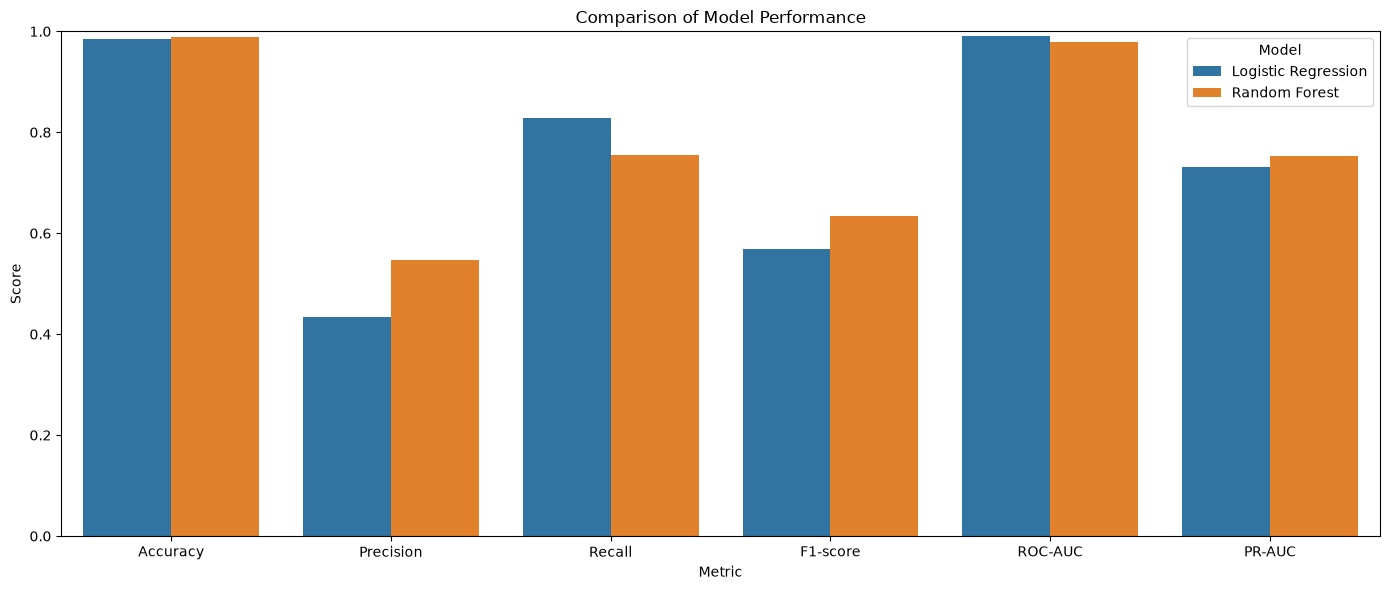

In [39]:
models = {
    "Logistic Regression": (y_test, y_pred_log, y_prob_log),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf)
}

results = []

for name, (yt, yp, ypr) in models.items():

    report = classification_report(
        yt,
        yp,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(yt, ypr),
        "PR-AUC": average_precision_score(yt, ypr)
    })

df_results = pd.DataFrame(results)

df_melted = df_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Comparison of Model Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()